# 02 — Titanic: predictive modelling (Part B)

**Module 2 · Zepto Data & AI Platform · `/analytics`**

Continues straight from `01_eda.ipynb`: the data comes from the **same `titanic.csv`** that notebook wrote (the single load of the raw dataset). There is **no** `sns.load_dataset` call in this notebook.

Contents: stratified split → leakage-safe `Pipeline`/`ColumnTransformer` → LR / Decision Tree / Random Forest with the full metric suite → imbalance comparison (baseline vs `class_weight` vs SMOTE) → `GridSearchCV` + OOB score → fare regression → comparison table + recommendation → `joblib` export and reload test.

Run with the working directory set to `/analytics`. Written interpretations are computed from the results and saved to `results/02_modeling_interpretations.md`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve,
                             mean_absolute_error, mean_squared_error, r2_score)
from imblearn.over_sampling import SMOTE          # pip install imbalanced-learn

try:
    from IPython.display import Markdown, display
except ImportError:
    Markdown = display = None

sns.set_theme(style="whitegrid")
RS = 42
os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)
os.makedirs("models", exist_ok=True)

REPORT = []


def say(md):
    REPORT.append(md)
    if display is not None:
        display(Markdown(md))
    else:
        print(md)


def save_fig(fig, name):
    fig.savefig(f"figures/{name}.png", dpi=150, bbox_inches="tight")


def show(obj):
    display(obj) if display is not None else print(obj)

## 1 · Load the shared CSV and choose features

Cleaning decisions carried over from `01_eda` — only the **stateless** ones are applied before the split:
- `deck` (> 30 % missing) is not used.
- Rows with missing `embarked` (< 5 %) are dropped.

Anything that *learns a statistic from the data* (median age, most-frequent category, scaling) is deliberately **not** done here; it lives inside the pipeline and is fitted on the training split only. Redundant/derived columns (`class`, `who`, `adult_male`, `alone`, `alive`, `embark_town`) are excluded because they duplicate `pclass`, `sex`, `age`, `sibsp + parch`, `survived`, `embarked`.

In [2]:
df = pd.read_csv("titanic.csv")                    # same file 01_eda.ipynb wrote — NOT a second sns.load_dataset
print("loaded titanic.csv:", df.shape)

NUM = ["pclass", "age", "sibsp", "parch", "fare"]
CAT = ["sex", "embarked"]
FEATURES = NUM + CAT
TARGET = "survived"

df = df.dropna(subset=["embarked"]).reset_index(drop=True)
X, y = df[FEATURES], df[TARGET]
print("model frame:", X.shape, "| missing per feature:\n", X.isna().sum()[X.isna().sum() > 0].to_dict())

loaded titanic.csv: (891, 15)
model frame: (889, 7) | missing per feature:
 {'age': 177}


## 2 · Class balance and the stratified split (before any preprocessing)

In [3]:
counts = y.value_counts().sort_index()
minority_share = counts.min() / counts.sum()
balance = pd.DataFrame({"count": counts.to_numpy(), "share": (counts / counts.sum()).round(4).to_numpy()}, index=["not survived (0)", "survived (1)"])
show(balance)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RS)
split_bal = pd.DataFrame({"train": y_train.value_counts(normalize=True).sort_index(),
                          "test": y_test.value_counts(normalize=True).sort_index()}).round(4)
show(split_bal)

say(f"**Why stratify?** The target is {"mildly " if 0.3 <= minority_share < 0.5 else ""}imbalanced: **{100 * counts[0] / counts.sum():.1f}%** of passengers did not survive and "
    f"**{100 * counts[1] / counts.sum():.1f}%** survived (minority share {100 * minority_share:.1f}%). "
    "A plain random split can, by chance, put noticeably more or fewer survivors in the test set, which shifts accuracy/recall and makes models look better or worse than they are. "
    f"`stratify=y` keeps the class ratio the same in both splits (train survived {100 * y_train.mean():.1f}%, test survived {100 * y_test.mean():.1f}%). "
    f"The split was done first (train n={len(X_train)}, test n={len(X_test)}), before any imputation, encoding or scaling.")

,count,share
not survived (0),549,0.6175
survived (1),340,0.3825


,train,test
survived,,
0,0.6174,0.618
1,0.3826,0.382


**Why stratify?** The target is mildly imbalanced: **61.8%** of passengers did not survive and **38.2%** survived (minority share 38.2%). A plain random split can, by chance, put noticeably more or fewer survivors in the test set, which shifts accuracy/recall and makes models look better or worse than they are. `stratify=y` keeps the class ratio the same in both splits (train survived 38.3%, test survived 38.2%). The split was done first (train n=711, test n=178), before any imputation, encoding or scaling.

## 3 · Leakage-safe preprocessing

`ColumnTransformer` (per-column imputing / one-hot / scaling) wrapped in a `Pipeline` together with the estimator. `Pipeline.fit(X_train, …)` fits the imputer, encoder and scaler on the **training split only**; `predict`/`predict_proba`/`transform` on the test split run in **transform-only** mode. Nothing is ever fitted on the test data or on the full pre-split frame.

Choices: numeric → median imputation (age is skewed) + `StandardScaler`; categorical (`sex`, `embarked`) → most-frequent imputation + one-hot encoding (`handle_unknown="ignore"` so unseen categories in new data don't crash).

In [4]:
def make_preprocessor():
    num = Pipeline([("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler())])
    cat = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore"))])
    return ColumnTransformer([("num", num, NUM), ("cat", cat, CAT)], verbose_feature_names_out=False)


def make_pipe(estimator):
    return Pipeline([("prep", make_preprocessor()), ("clf", estimator)])


def pct(x):
    return f"{100 * x:.1f}%"

## 4 · Three classifiers on the identical split

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RS),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=RS),   # shallow -> readable, less overfit
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RS),
}
fitted = {name: make_pipe(est).fit(X_train, y_train) for name, est in models.items()}   # fit on TRAIN only


def evaluate(pipe, Xt, yt):
    pred = pipe.predict(Xt)
    proba = pipe.predict_proba(Xt)[:, 1]
    tn, fp, fn, tp = confusion_matrix(yt, pred).ravel()
    return {"TN": tn, "FP": fp, "FN": fn, "TP": tp,
            "Accuracy": accuracy_score(yt, pred), "Precision": precision_score(yt, pred, zero_division=0),
            "Recall": recall_score(yt, pred), "F1": f1_score(yt, pred), "AUC": roc_auc_score(yt, proba)}, pred, proba


# ---- leakage audit: the fitted preprocessing statistics must equal TRAIN-only statistics ----
num_pipe = fitted["Logistic Regression"].named_steps["prep"].named_transformers_["num"]
train_median = X_train[NUM].median().to_numpy()
train_mean_after_impute = X_train[NUM].fillna(X_train[NUM].median()).mean().to_numpy()
assert np.allclose(num_pipe.named_steps["imputer"].statistics_, train_median), "imputer was not fitted on train only"
assert np.allclose(num_pipe.named_steps["scaler"].mean_, train_mean_after_impute), "scaler was not fitted on train only"
full_median_age = X["age"].median()
print(f"leakage audit passed: imputer/scaler statistics match the training split "
      f"(train median age = {X_train['age'].median():.2f} vs full-data median age = {full_median_age:.2f})")

results, preds, probas = {}, {}, {}
for name, pipe in fitted.items():
    results[name], preds[name], probas[name] = evaluate(pipe, X_test, y_test)

clf_table = pd.DataFrame(results).T
clf_table[["TN", "FP", "FN", "TP"]] = clf_table[["TN", "FP", "FN", "TP"]].astype(int)
show(clf_table.round(4))

leakage audit passed: imputer/scaler statistics match the training split (train median age = 28.00 vs full-data median age = 28.00)


,TN,FP,FN,TP,Accuracy,Precision,Recall,F1,AUC
Logistic Regression,97,13,21,47,0.8090,0.7833,0.6912,0.7344,0.8610
Decision Tree,97,13,23,45,0.7978,0.7759,0.6618,0.7143,0.8510
Random Forest,95,15,20,48,0.8034,0.7619,0.7059,0.7328,0.8237


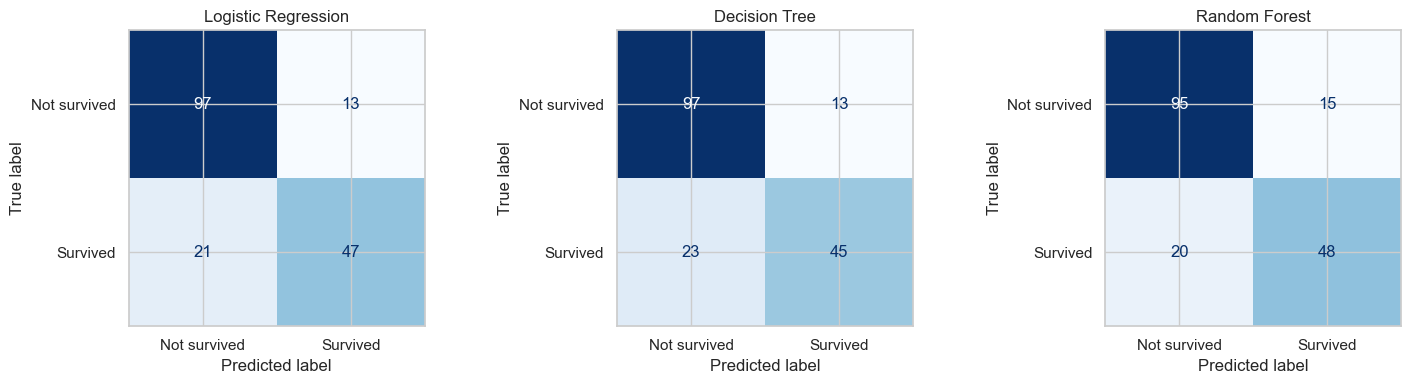

In [6]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name in zip(axes, fitted):
    ConfusionMatrixDisplay.from_predictions(y_test, preds[name], display_labels=["Not survived", "Survived"],
                                            ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.tight_layout(); save_fig(fig, "confusion_matrices"); plt.show()

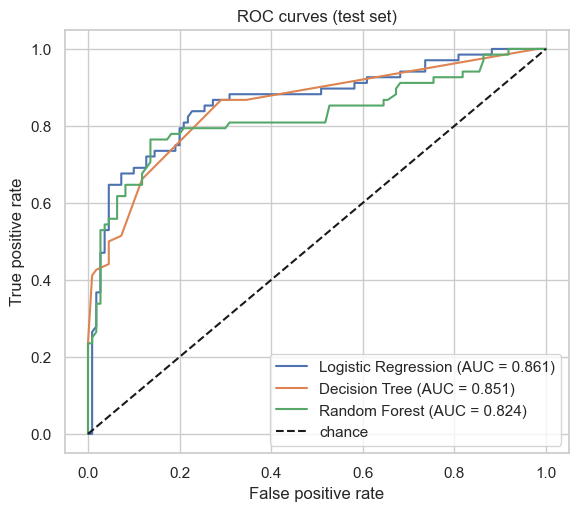

In [7]:
# ROC curves + AUC
fig, ax = plt.subplots(figsize=(6.5, 5.5))
for name in fitted:
    fpr, tpr, _ = roc_curve(y_test, probas[name])
    ax.plot(fpr, tpr, label=f"{name} (AUC = {results[name]['AUC']:.3f})")
ax.plot([0, 1], [0, 1], "k--", label="chance")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate"); ax.set_title("ROC curves (test set)")
ax.legend(loc="lower right")
save_fig(fig, "roc_curves"); plt.show()

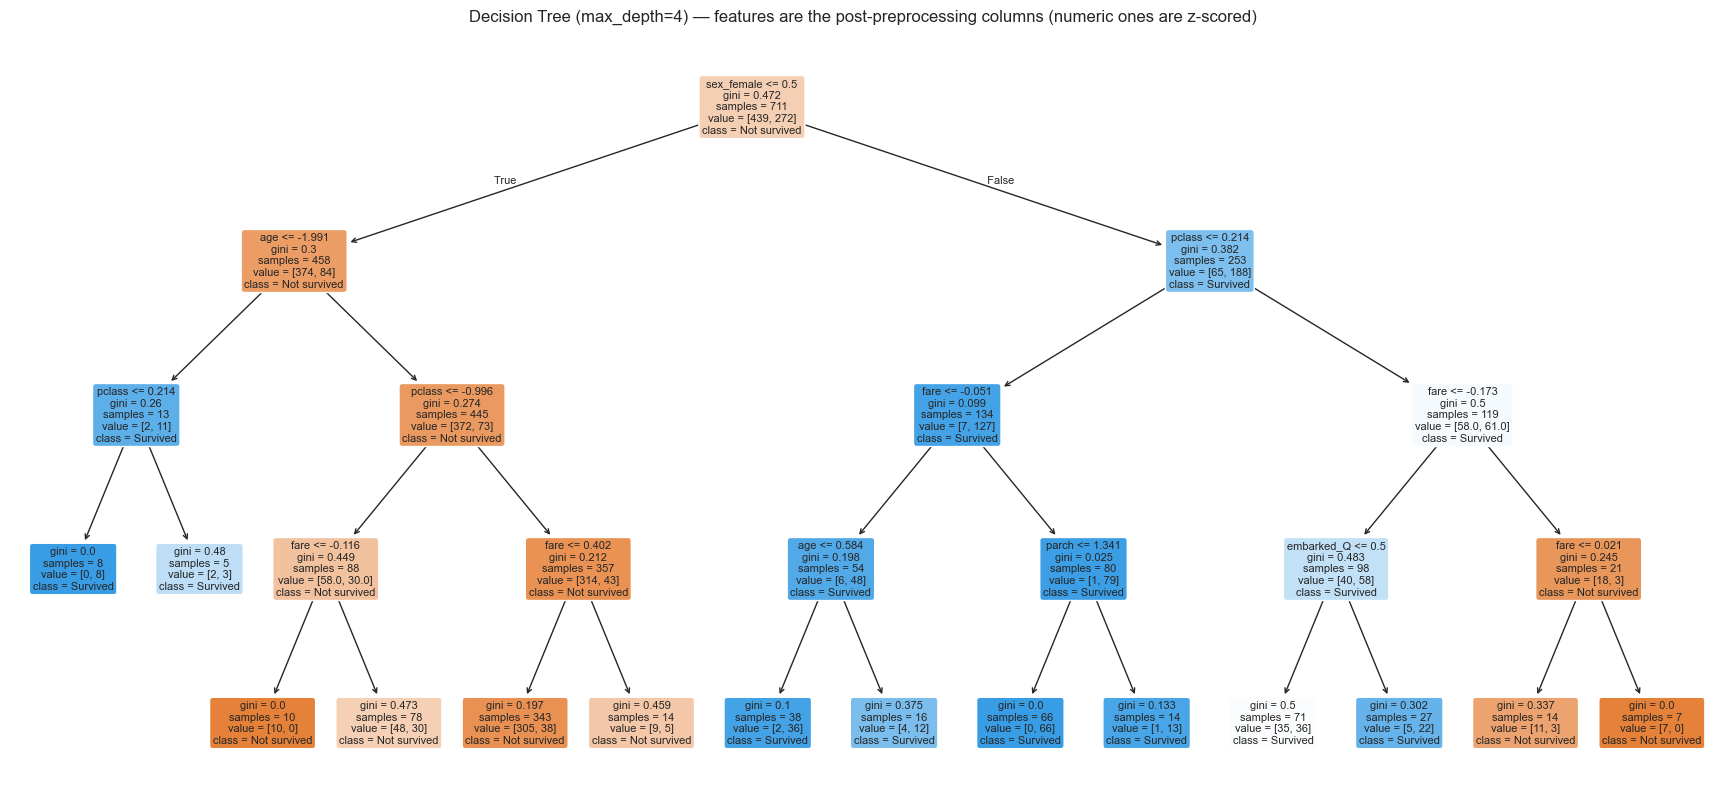

In [8]:
# Decision tree with labelled features and classes
dt_pipe = fitted["Decision Tree"]
feat_names = list(dt_pipe.named_steps["prep"].get_feature_names_out())
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(dt_pipe.named_steps["clf"], feature_names=feat_names, class_names=["Not survived", "Survived"],
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title("Decision Tree (max_depth=4) — features are the post-preprocessing columns (numeric ones are z-scored)")
save_fig(fig, "decision_tree"); plt.show()

## 5 · Imbalance handling: baseline vs `class_weight='balanced'` vs SMOTE

Logistic Regression is used for all three variants. SMOTE is applied **only to the training data** (after the preprocessor has been fitted on the training split); the test set is only transformed and never resampled.

In [9]:
print("class balance -> overall:", counts.to_dict(), "| train:", y_train.value_counts().sort_index().to_dict(),
      "| test:", y_test.value_counts().sort_index().to_dict())

variants = {}

# (a) baseline
base = make_pipe(LogisticRegression(max_iter=1000, random_state=RS)).fit(X_train, y_train)
variants["(a) Baseline"] = base.predict(X_test)

# (b) class_weight='balanced'
bal = make_pipe(LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RS)).fit(X_train, y_train)
variants["(b) class_weight='balanced'"] = bal.predict(X_test)

# (c) SMOTE on the training fold only
prep_smote = make_preprocessor()
Xtr_t = prep_smote.fit_transform(X_train)                       # fitted on train
Xtr_res, ytr_res = SMOTE(random_state=RS).fit_resample(Xtr_t, y_train)   # resample TRAIN ONLY
clf_smote = LogisticRegression(max_iter=1000, random_state=RS).fit(Xtr_res, ytr_res)
variants["(c) SMOTE (train only)"] = clf_smote.predict(prep_smote.transform(X_test))       # test: transform only
print(f"SMOTE: train {len(y_train)} -> {len(ytr_res)} rows (class counts now {pd.Series(ytr_res).value_counts().sort_index().to_dict()}); test untouched ({len(y_test)} rows)")

imb_tbl = pd.DataFrame({k: {"Precision": precision_score(y_test, v, zero_division=0), "Recall": recall_score(y_test, v),
                            "F1": f1_score(y_test, v)} for k, v in variants.items()}).T
show(imb_tbl.round(4))

class balance -> overall: {0: 549, 1: 340} | train: {0: 439, 1: 272} | test: {0: 110, 1: 68}
SMOTE: train 711 -> 878 rows (class counts now {0: 439, 1: 439}); test untouched (178 rows)


,Precision,Recall,F1
(a) Baseline,0.7833,0.6912,0.7344
(b) class_weight='balanced',0.7183,0.7500,0.7338
(c) SMOTE (train only),0.7353,0.7353,0.7353


In [10]:
best_v = imb_tbl["F1"].idxmax()
d_f1 = imb_tbl.loc[best_v, "F1"] - imb_tbl.loc["(a) Baseline", "F1"]
d_rec = imb_tbl["Recall"].idxmax()
if best_v == "(a) Baseline" or abs(d_f1) < 0.01:
    verdict = ("No strategy gives a meaningful F1 improvement over the baseline "
               f"(best F1 {imb_tbl.loc[best_v, 'F1']:.3f} for {best_v}, only {d_f1:+.3f} vs baseline), which is expected because the imbalance is mild "
               f"({100 * minority_share:.0f}% minority) and differences of this size on one {len(y_test)}-row test set are within noise.")
else:
    verdict = (f"**{best_v}** performed best on F1 ({imb_tbl.loc[best_v, 'F1']:.3f}, {d_f1:+.3f} vs the baseline's "
               f"{imb_tbl.loc['(a) Baseline', 'F1']:.3f}).")
base_p, base_r = imb_tbl.loc["(a) Baseline", "Precision"], imb_tbl.loc["(a) Baseline", "Recall"]
tradeoff = (f"at the cost of precision ({imb_tbl.loc[d_rec, 'Precision']:.3f} vs {base_p:.3f})"
            if imb_tbl.loc[d_rec, "Precision"] < base_p else "without losing precision")
say("**Imbalance-handling conclusion.** " + verdict +
    f" Recall (survivors caught) was highest for {d_rec} ({imb_tbl.loc[d_rec, 'Recall']:.3f} vs baseline {base_r:.3f}), {tradeoff}. "
    "Both re-weighting and oversampling push the decision boundary toward the minority class, which is why recall moves first. "
    "`class_weight='balanced'` is the cheapest option (no synthetic rows, no extra dependency), whereas SMOTE builds synthetic survivors by interpolation and, "
    "because it runs on one-hot columns, can create fractional dummy values, so it is mainly worth its complexity when imbalance is severe. "
    "SMOTE was fitted on the training rows only, so no synthetic sample leaks into the test evaluation.")

**Imbalance-handling conclusion.** No strategy gives a meaningful F1 improvement over the baseline (best F1 0.735 for (c) SMOTE (train only), only +0.001 vs baseline), which is expected because the imbalance is mild (38% minority) and differences of this size on one 178-row test set are within noise. Recall (survivors caught) was highest for (b) class_weight='balanced' (0.750 vs baseline 0.691), at the cost of precision (0.718 vs 0.783). Both re-weighting and oversampling push the decision boundary toward the minority class, which is why recall moves first. `class_weight='balanced'` is the cheapest option (no synthetic rows, no extra dependency), whereas SMOTE builds synthetic survivors by interpolation and, because it runs on one-hot columns, can create fractional dummy values, so it is mainly worth its complexity when imbalance is severe. SMOTE was fitted on the training rows only, so no synthetic sample leaks into the test evaluation.

## 6 · Hyper-parameter tuning: Random Forest with `GridSearchCV` and OOB score

The forest is constructed with `oob_score=True` (otherwise `oob_score_` is not populated). The grid covers `n_estimators`, `max_depth` and `max_features`; 5-fold stratified CV inside the training split, scored by F1.

In [11]:
rf_oob = make_pipe(RandomForestClassifier(oob_score=True, bootstrap=True, random_state=RS))
param_grid = {
    "clf__n_estimators": [100, 200, 400],
    "clf__max_depth": [3, 5, 8, None],
    "clf__max_features": ["sqrt", "log2", None],
}
gs = GridSearchCV(rf_oob, param_grid, cv=StratifiedKFold(5, shuffle=True, random_state=RS),
                  scoring="f1", n_jobs=-1, refit=True)
gs.fit(X_train, y_train)                                       # train split only

best_rf = gs.best_estimator_
oob = best_rf.named_steps["clf"].oob_score_
print("best params:", gs.best_params_)
print(f"best CV F1: {gs.best_score_:.4f} | OOB score (accuracy on out-of-bag samples): {oob:.4f}")
top_cv = (pd.DataFrame(gs.cv_results_)[["param_clf__n_estimators", "param_clf__max_depth", "param_clf__max_features", "mean_test_score"]]
          .sort_values("mean_test_score", ascending=False).head(5))
show(top_cv.round(4))

results["Random Forest (tuned)"], preds["Random Forest (tuned)"], probas["Random Forest (tuned)"] = evaluate(best_rf, X_test, y_test)
fitted["Random Forest (tuned)"] = best_rf

say(f"**Tuning result.** Best combination: `{gs.best_params_}` with mean 5-fold CV F1 = **{gs.best_score_:.3f}** and "
    f"**OOB score = {oob:.3f}** (accuracy on samples each tree did not see; an almost free, independent validation estimate). "
    f"On the held-out test set the tuned forest reaches F1 = {results['Random Forest (tuned)']['F1']:.3f} and AUC = {results['Random Forest (tuned)']['AUC']:.3f}, "
    f"versus F1 = {results['Random Forest']['F1']:.3f} / AUC = {results['Random Forest']['AUC']:.3f} for the untuned forest.")

best params: {'clf__max_depth': 8, 'clf__max_features': None, 'clf__n_estimators': 400}
best CV F1: 0.7722 | OOB score (accuracy on out-of-bag samples): 0.8326


,param_clf__n_estimators,param_clf__max_depth,param_clf__max_features,mean_test_score
26,400,8,None,0.7722
24,100,8,None,0.7685
18,100,8,sqrt,0.7628
21,100,8,log2,0.7628
35,400,None,None,0.7627


**Tuning result.** Best combination: `{'clf__max_depth': 8, 'clf__max_features': None, 'clf__n_estimators': 400}` with mean 5-fold CV F1 = **0.772** and **OOB score = 0.833** (accuracy on samples each tree did not see; an almost free, independent validation estimate). On the held-out test set the tuned forest reaches F1 = 0.762 and AUC = 0.841, versus F1 = 0.733 / AUC = 0.824 for the untuned forest.

## 7 · Regression side-task: predict `fare`

Multivariate linear regression from `pclass, age, sex, sibsp, parch, embarked` (same preprocessing recipe, fitted on the regression training split). `survived` and `fare`-derived columns are excluded: `survived` is an outcome, not something known when a ticket is priced.

In [12]:
R_NUM = ["pclass", "age", "sibsp", "parch"]
R_CAT = ["sex", "embarked"]
Xr, yr = df[R_NUM + R_CAT], df["fare"]
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=0.2, random_state=RS)

reg_prep = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), R_NUM),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), R_CAT),
], verbose_feature_names_out=False)
reg = Pipeline([("prep", reg_prep), ("lr", LinearRegression())]).fit(Xr_tr, yr_tr)

pred_r = reg.predict(Xr_te)
resid = yr_te.to_numpy() - pred_r
n, p = len(yr_te), len(reg.named_steps["prep"].get_feature_names_out())
r2 = r2_score(yr_te, pred_r)
reg_metrics = {"MAE": mean_absolute_error(yr_te, pred_r),
               "RMSE": float(np.sqrt(mean_squared_error(yr_te, pred_r))),
               "R²": r2,
               "Adj. R²": 1 - (1 - r2) * (n - 1) / (n - p - 1)}
show(pd.Series(reg_metrics, name="test-set value").round(4).to_frame())

,test-set value
MAE,21.1398
RMSE,41.7465
R²,0.3468
Adj. R²,0.3118


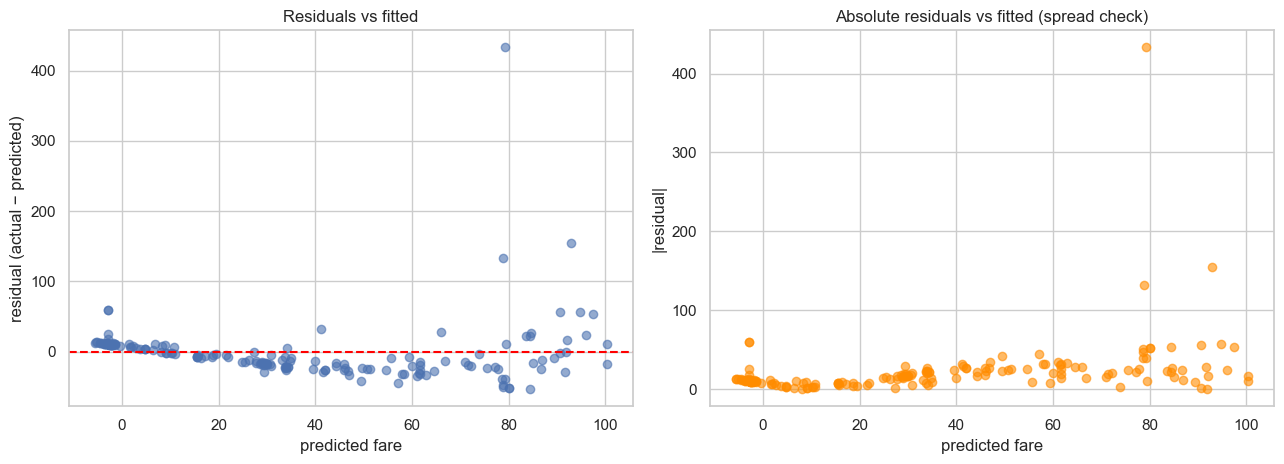

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].scatter(pred_r, resid, alpha=0.6); axes[0].axhline(0, color="red", ls="--")
axes[0].set_xlabel("predicted fare"); axes[0].set_ylabel("residual (actual − predicted)"); axes[0].set_title("Residuals vs fitted")
axes[1].scatter(pred_r, np.abs(resid), alpha=0.6, color="darkorange")
axes[1].set_xlabel("predicted fare"); axes[1].set_ylabel("|residual|"); axes[1].set_title("Absolute residuals vs fitted (spread check)")
plt.tight_layout(); save_fig(fig, "regression_residuals"); plt.show()

In [14]:
# Heteroscedasticity: Koenker/Breusch-Pagan-style test -> regress squared residuals on fitted values, LM = n * R^2 ~ chi2(1)
aux = LinearRegression().fit(pred_r.reshape(-1, 1), resid ** 2)
lm = n * aux.score(pred_r.reshape(-1, 1), resid ** 2)
p_bp = stats.chi2.sf(lm, df=1)
rho, p_rho = stats.spearmanr(pred_r, np.abs(resid))
hetero = (p_bp < 0.05) or (p_rho < 0.05)
lo_half = resid[pred_r <= np.median(pred_r)]; hi_half = resid[pred_r > np.median(pred_r)]
ratio = hi_half.var() / lo_half.var()
say(f"**Residual analysis.** Test metrics: MAE = {reg_metrics['MAE']:.2f}, RMSE = {reg_metrics['RMSE']:.2f}, "
    f"R² = {reg_metrics['R²']:.3f}, Adjusted R² = {reg_metrics['Adj. R²']:.3f}. "
    f"Residual variance in the upper half of predicted fares is **{ratio:.1f}×** that in the lower half; the Breusch-Pagan-style test gives LM = {lm:.2f} (p = {p_bp:.3g}) "
    f"and |residual| vs fitted has Spearman ρ = {rho:.2f} (p = {p_rho:.3g}). "
    + ("**Conclusion: the residual plot shows heteroscedasticity** — the spread of the errors is not constant but grows with the predicted fare (a funnel shape), "
       "which violates the constant-variance assumption of ordinary least squares. This is expected because fare is strongly right-skewed; "
       "modelling `log(fare)` or using a robust/tree-based regressor would be the natural fix."
       if hetero else
       "**Conclusion: no clear heteroscedasticity** — the residual spread looks roughly constant across the predicted range and both tests are non-significant at 5%."))

**Residual analysis.** Test metrics: MAE = 21.14, RMSE = 41.75, R² = 0.347, Adjusted R² = 0.312. Residual variance in the upper half of predicted fares is **18.7×** that in the lower half; the Breusch-Pagan-style test gives LM = 4.18 (p = 0.0408) and |residual| vs fitted has Spearman ρ = 0.52 (p = 1.36e-13). **Conclusion: the residual plot shows heteroscedasticity** — the spread of the errors is not constant but grows with the predicted fare (a funnel shape), which violates the constant-variance assumption of ordinary least squares. This is expected because fare is strongly right-skewed; modelling `log(fare)` or using a robust/tree-based regressor would be the natural fix.

## 8 · Model comparison table and recommendation

Classification metrics and regression metrics are on different scales and are **not comparable**, so they are shown as two separate metric groups; the other group is left blank for each row.

In [15]:
CLS_COLS = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
REG_COLS = ["MAE", "RMSE", "R²", "Adj. R²"]
cls_rows = ["Logistic Regression", "Decision Tree", "Random Forest", "Random Forest (tuned)"]

cmp_df = pd.DataFrame(index=cls_rows + ["Linear Regression (fare)"],
                      columns=pd.MultiIndex.from_tuples([("Classification (survived)", c) for c in CLS_COLS] +
                                                        [("Regression (fare)", c) for c in REG_COLS]), dtype=float)
for name in cls_rows:
    for c in CLS_COLS:
        cmp_df.loc[name, ("Classification (survived)", c)] = results[name][c]
for c in REG_COLS:
    cmp_df.loc["Linear Regression (fare)", ("Regression (fare)", c)] = reg_metrics[c]
show(cmp_df.round(3))


def to_markdown(frame, digits=3):
    cols = [f"{a}: {b}" for a, b in frame.columns]
    out = ["| Model | " + " | ".join(cols) + " |", "|---|" + "---|" * len(cols)]
    for idx, row in frame.iterrows():
        out.append(f"| {idx} | " + " | ".join("" if pd.isna(v) else f"{v:.{digits}f}" for v in row) + " |")
    return "\n".join(out)


md_table = to_markdown(cmp_df)
note = ("_Classification and regression metrics are on different scales and are not directly comparable; "
        "they are shown as two separate metric groups. All values are on the held-out test set._")

Classification (survived)                          \
                                          Accuracy Precision Recall     F1   
Logistic Regression                          0.809     0.783  0.691  0.734   
Decision Tree                                0.798     0.776  0.662  0.714   
Random Forest                                0.803     0.762  0.706  0.733   
Random Forest (tuned)                        0.831     0.828  0.706  0.762   
Linear Regression (fare)                       NaN       NaN    NaN    NaN   

                                Regression (fare)                         
                            AUC               MAE    RMSE     R² Adj. R²  
Logistic Regression       0.861               NaN     NaN    NaN     NaN  
Decision Tree             0.851               NaN     NaN    NaN     NaN  
Random Forest             0.824               NaN     NaN    NaN     NaN  
Random Forest (tuned)     0.841               NaN     NaN    NaN     NaN  
Linear Regression (fare)    NaN             21.14  41.747  0.347   0.312

In [16]:
ranked = sorted(cls_rows, key=lambda m: (results[m]["F1"], results[m]["AUC"]), reverse=True)
best_name, runner = ranked[0], ranked[1]
b, r_ = results[best_name], results[runner]
lr_r = results["Logistic Regression"]
BLURB = {
    "Logistic Regression": "It is also linear and transparent, so its coefficients are easy to audit and explain.",
    "Decision Tree": "It is also the most interpretable option (the tree can be read top to bottom), but a single tree is high-variance, so I would re-validate it on fresh data before trusting it.",
    "Random Forest": "As an ensemble of trees it is more stable than a single tree, at the cost of being harder to explain.",
    "Random Forest (tuned)": "As a tuned ensemble it is more stable than a single tree and its OOB score gives a second, independent estimate, at the cost of being harder to explain.",
}
margin = b["F1"] - r_["F1"]
lr_line = ("" if best_name == "Logistic Regression" else
           f" For reference, the Logistic Regression baseline scores F1 {lr_r['F1']:.3f} / AUC {lr_r['AUC']:.3f}, so any extra complexity should be judged against that.")
recommendation = (
    f"I would deploy **{best_name}** (ranked by test F1, with AUC as tie-breaker): F1 {b['F1']:.3f}, AUC {b['AUC']:.3f}, accuracy {b['Accuracy']:.3f}, "
    f"precision {b['Precision']:.3f}, recall {b['Recall']:.3f}. "
    f"The runner-up, {runner}, scores F1 {r_['F1']:.3f} / AUC {r_['AUC']:.3f}, a margin of {margin:.3f} F1"
    + (", which is within noise, so stability and explainability should also weigh in. " if margin < 0.02 else ". ")
    + BLURB[best_name] + lr_line
    + f" Caveat: this is one 20% split ({len(y_test)} test rows), and the tuned forest's OOB score is {oob:.3f}; "
    "the regression model is a separate task and is not ranked against the classifiers.")
say("**Final recommendation.** " + recommendation)

with open("results/model_comparison.md", "w", encoding="utf-8") as fh:
    fh.write("# Model comparison (test set)\n\n" + md_table + "\n\n" + note + "\n\n## Final recommendation\n\n" + recommendation + "\n")
cmp_df.columns = [f"{a} | {b}" for a, b in cmp_df.columns]
cmp_df.round(4).to_csv("results/model_comparison.csv")
print("saved results/model_comparison.md and .csv")

**Final recommendation.** I would deploy **Random Forest (tuned)** (ranked by test F1, with AUC as tie-breaker): F1 0.762, AUC 0.841, accuracy 0.831, precision 0.828, recall 0.706. The runner-up, Logistic Regression, scores F1 0.734 / AUC 0.861, a margin of 0.028 F1. As a tuned ensemble it is more stable than a single tree and its OOB score gives a second, independent estimate, at the cost of being harder to explain. For reference, the Logistic Regression baseline scores F1 0.734 / AUC 0.861, so any extra complexity should be judged against that. Caveat: this is one 20% split (178 test rows), and the tuned forest's OOB score is 0.833; the regression model is a separate task and is not ranked against the classifiers.

saved results/model_comparison.md and .csv


## 9 · Save the complete pipeline with `joblib` and prove it works on raw data

The saved object is the **whole fitted `Pipeline`** (imputer + encoder + scaler + estimator), not the bare estimator.

In [17]:
best_pipeline = fitted[best_name]
PATH = "models/best_pipeline.joblib"
joblib.dump(best_pipeline, PATH)
print(f"saved {best_name} -> {PATH} ({os.path.getsize(PATH) / 1024:.0f} KB)")

saved Random Forest (tuned) -> models/best_pipeline.joblib (3827 KB)


In [18]:
loaded = joblib.load(PATH)
print("steps in loaded object:", [name for name, _ in loaded.steps])

# raw, un-preprocessed new passengers (note the missing age and the missing embarked value)
new_raw = pd.DataFrame([
    {"pclass": 1, "sex": "female", "age": 29, "sibsp": 0, "parch": 0, "fare": 120.0, "embarked": "C"},
    {"pclass": 3, "sex": "male", "age": np.nan, "sibsp": 0, "parch": 0, "fare": 7.9, "embarked": None},
    {"pclass": 2, "sex": "female", "age": 8, "sibsp": 1, "parch": 2, "fare": 26.0, "embarked": "S"},
])
print(pd.DataFrame({"P(survived)": loaded.predict_proba(new_raw)[:, 1].round(3), "predicted": loaded.predict(new_raw)}))

# consistency: identical predictions to the in-memory pipeline on the untouched raw test split
assert np.array_equal(loaded.predict(X_test), best_pipeline.predict(X_test))
assert np.allclose(loaded.predict_proba(X_test), best_pipeline.predict_proba(X_test))
acc_loaded = accuracy_score(y_test, loaded.predict(X_test))
print(f"reloaded pipeline test accuracy = {acc_loaded:.4f} (in-memory: {accuracy_score(y_test, best_pipeline.predict(X_test)):.4f}) -> identical")

# even the full raw CSV rows (extra columns, NaNs and all) work, because the ColumnTransformer selects columns by name
print("raw CSV rows ->", loaded.predict(pd.read_csv("titanic.csv").head(5)))

say(f"**Saved artifact.** `{PATH}` contains the full fitted `Pipeline` for **{best_name}** (steps: {[n for n, _ in loaded.steps]}). "
    f"Reloading it with `joblib.load` and predicting on raw data (including a missing age and a missing port) works without any manual preprocessing, "
    f"and its predictions on the raw test split are identical to the in-memory pipeline (accuracy {acc_loaded:.3f}).")

steps in loaded object: ['prep', 'clf']
   P(survived)  predicted
0        1.000          1
1        0.055          0
2        0.939          1
reloaded pipeline test accuracy = 0.8315 (in-memory: 0.8315) -> identical
raw CSV rows -> [0 1 1 1 0]


**Saved artifact.** `models/best_pipeline.joblib` contains the full fitted `Pipeline` for **Random Forest (tuned)** (steps: ['prep', 'clf']). Reloading it with `joblib.load` and predicting on raw data (including a missing age and a missing port) works without any manual preprocessing, and its predictions on the raw test split are identical to the in-memory pipeline (accuracy 0.831).

In [19]:
with open("results/02_modeling_interpretations.md", "w", encoding="utf-8") as fh:
    fh.write("# Modelling written interpretations (auto-generated by 02_modeling.ipynb)\n\n" + "\n\n".join(REPORT) + "\n")
print("saved results/02_modeling_interpretations.md")

saved results/02_modeling_interpretations.md
